# Benchmarking

In [31]:
# Import python modules
import os
import sys
import pandas as pd

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [32]:
# Import custom modules
import plotting
import utils

In [33]:
BASE_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(BASE_FOLDER, "runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")

DATA_FOLDER = os.path.join(BASE_FOLDER, "data")
FOR_THE_REPORT_FOLDER = os.path.join(DATA_FOLDER, "for_the_report")
METHODOLOGY_FOLDER = os.path.join(FOR_THE_REPORT_FOLDER, "methodology")
BENCHMARKING_FOLDER = os.path.join(METHODOLOGY_FOLDER, "benchmarking")
os.makedirs(BENCHMARKING_FOLDER, exist_ok=True)

In [34]:
folder_names_to_benchmark = [
    "batch_128_benchmark_2_4_8_x5_1core",
    "batch_128_benchmark_2_4_8_x5_2core",
    "batch_128_benchmark_2_4_8_x5_4core",
]

In [35]:
folders_to_benchmark = [
    os.path.join(BATCH_RUNS_FOLDER, folder_name)
    for folder_name in folder_names_to_benchmark
]
folders_to_benchmark

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_benchmark_2_4_8_x5_1core',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_benchmark_2_4_8_x5_2core',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_benchmark_2_4_8_x5_4core']

In [36]:
tables_folder = BENCHMARKING_FOLDER
figures_folder = BENCHMARKING_FOLDER

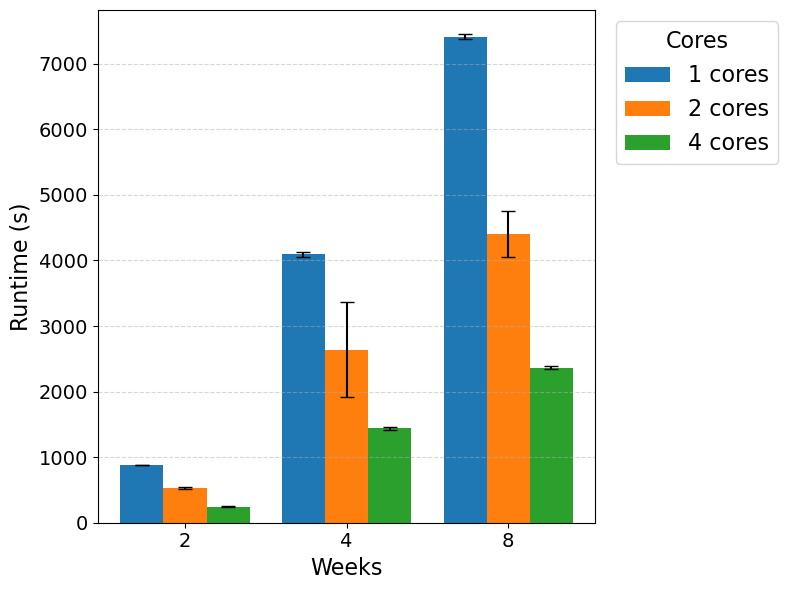

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def assemble_model_info(folders: list[str]) -> pd.DataFrame:
    """
    Traverse benchmark folders and read the first row of each model_info.csv,
    collecting all columns plus 'cores' and 'weeks'.
    """
    records = []
    for folder in folders:
        # Extract number of cores from folder name (e.g. '..._1core')
        core = int(os.path.basename(folder).split("_")[-1].replace("core", ""))
        for run_dir in os.listdir(folder):
            run_path = os.path.join(folder, run_dir)
            if not os.path.isdir(run_path):
                continue
            # Determine run number (prefix before '_')
            try:
                run_num = int(run_dir.split("_")[0])
            except ValueError:
                continue
            # Map run number to weeks
            if 1 <= run_num <= 5:
                weeks = 2
            elif 6 <= run_num <= 10:
                weeks = 4
            elif 11 <= run_num <= 15:
                weeks = 8
            else:
                continue
            # Locate model_info.csv
            info_path = os.path.join(run_path, "model_info", "model_info.csv")
            if not os.path.exists(info_path):
                continue
            # Read the header and first data row
            df_info = pd.read_csv(info_path, header=0, nrows=1)
            row = df_info.iloc[0]
            # Build record with all columns
            record = {"cores": core, "weeks": weeks}
            for col in df_info.columns:
                record[col] = row[col]
            records.append(record)
    return pd.DataFrame(records)


# 1) Assemble full model info table
df_info = assemble_model_info(folders_to_benchmark)

# 2) Save full table if desired
if tables_folder:
    df_info.to_csv(os.path.join(tables_folder, "model_info_full.csv"), index=False)

# 3) Compute runtime stats by weeks & cores
stats = (
    df_info.groupby(["weeks", "cores"])["Runtime (s)"]
    .agg(mean="mean", std="std")
    .reset_index()
)
if tables_folder:
    stats.to_csv(os.path.join(tables_folder, "runtime_stats.csv"), index=False)

# 4) Plot grouped bar chart of runtime
weeks = sorted(stats["weeks"].unique())
cores = sorted(stats["cores"].unique())
x = np.arange(len(weeks))
width = 0.8 / len(cores)

fig, ax = plt.subplots(figsize=(8, 6))
for i, core in enumerate(cores):
    sub = stats[stats["cores"] == core].set_index("weeks").reindex(weeks)
    means = sub["mean"].values
    stds = sub["std"].values
    offsets = x - 0.4 + (i + 0.5) * width
    ax.bar(offsets, means, width, yerr=stds, capsize=5, label=f"{core} cores")

# Styling
ax.set_xlabel("Weeks", fontsize=16)
ax.set_ylabel("Runtime (s)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels([str(w) for w in weeks], fontsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.legend(
    title="Cores",
    fontsize=16,
    title_fontsize=16,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# 5) Save plot
if figures_folder:
    fig.savefig(
        os.path.join(figures_folder, "runtime_by_weeks_cores.png"), bbox_inches="tight"
    )

In [38]:
def plot_runtime_by_weeks_cores_minutes(
    stats: pd.DataFrame, savefolder: str | None = None
) -> None:
    """
    Grouped bar chart of mean runtime (minutes) by weeks & cores with ±1 std (minutes).
    """
    # Convert seconds to minutes
    stats = stats.copy()
    stats["mean_min"] = stats["mean"] / 60
    stats["std_min"] = stats["std"] / 60

    weeks = sorted(stats["weeks"].unique())
    cores = sorted(stats["cores"].unique())
    x = np.arange(len(weeks))
    width = 0.8 / len(cores)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, core in enumerate(cores):
        sub = stats[stats["cores"] == core].set_index("weeks").reindex(weeks)
        means = sub["mean_min"].values
        stds = sub["std_min"].values
        offsets = x - 0.4 + (i + 0.5) * width
        ax.bar(offsets, means, width, yerr=stds, capsize=5, label=f"{core} cores")

    # Styling
    ax.set_xlabel("Weeks", fontsize=16)
    ax.set_ylabel("Runtime (minutes)", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels([str(w) for w in weeks], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.legend(
        title="Cores",
        fontsize=16,
        title_fontsize=16,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    print("Runtime by Weeks & Cores (minutes)")
    plt.show()

    # Save
    if savefolder:
        fig.savefig(
            os.path.join(savefolder, "runtime_by_weeks_cores_minutes.png"),
            bbox_inches="tight",
        )

Runtime by Weeks & Cores (minutes)


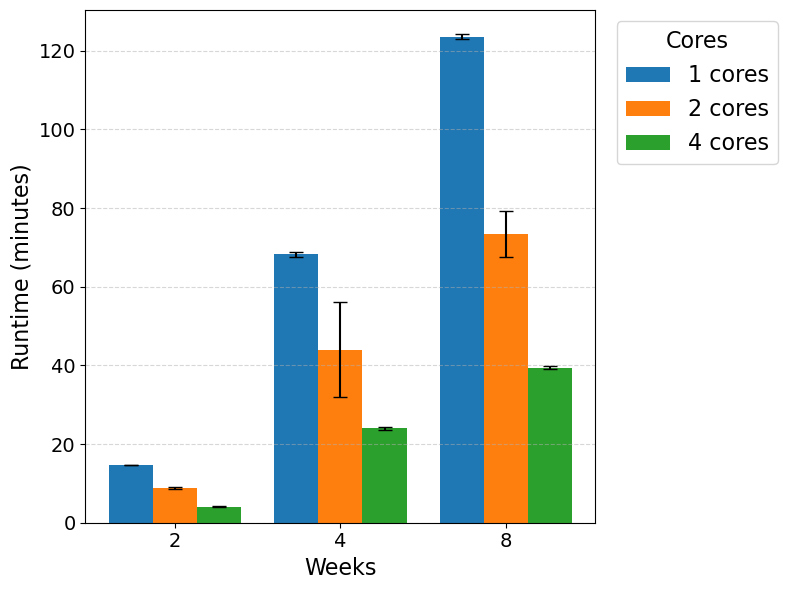

In [39]:
plot_runtime_by_weeks_cores_minutes(stats, savefolder=figures_folder)

In [42]:
import pandas as pd
import os


def make_example_week_comparison_table(
    df_info: pd.DataFrame,
    examples_per_week: dict[int, dict[str, int]],
    savefolder: str | None = None,
) -> pd.DataFrame:
    """
    Build a comparison table for specified example runs for each week setting.

    Parameters
    ----------
    df_info : pd.DataFrame
        Full model info table with columns including:
        'weeks', 'folder', 'Objective Value', 'Number of Variables',
        'Number of Constraints', 'Number of Nonzeros', etc.
    examples_per_week : dict
        Mapping from week -> dict specifying which example to pick:
        e.g. {2: {'cores': 1}, 4: {'cores': 1}, 8: {'cores': 1}}
        Or specify an index directly if needed.
    savefolder : str or None
        Directory to save the table CSV. If None, not saved.

    Returns
    -------
    pd.DataFrame
        Indexed by 'weeks', columns:
          'Objective Value', 'Number of Variables',
          'Number of Constraints', 'Number of Nonzeros'
    """
    rows = []
    for weeks, criteria in examples_per_week.items():
        # filter by weeks
        subset = df_info[df_info["weeks"] == weeks]
        # further filter by criteria keys (e.g. cores)
        for key, val in criteria.items():
            subset = subset[subset[key] == val]
        if subset.empty:
            continue
        # pick first example
        ex = subset.iloc[0]
        rows.append(
            {
                "weeks": weeks,
                "Objective Value": ex["Objective Value"],
                "Number of Variables": ex["Number of Variables"],
                "Number of Constraints": ex["Number of Constraints"],
                "Number of Nonzeros": ex["Number of Nonzeros"],
            }
        )
    table = pd.DataFrame(rows).set_index("weeks")
    if savefolder:
        table.to_csv(os.path.join(savefolder, "week_example_comparison.csv"))
    return table

In [43]:
examples = {
    2: {"cores": 1},
    4: {"cores": 1},
    8: {"cores": 1},
}
comparison_table = make_example_week_comparison_table(
    df_info, examples, savefolder=tables_folder
)

In [44]:
comparison_table

,Objective Value,Number of Variables,Number of Constraints,Number of Nonzeros
weeks,,,,
2,2.689875e+10,948168.0,720482.0,1936011.0
4,2.252673e+10,1895688.0,1440348.0,3869565.0
8,2.531806e+10,3790728.0,2880080.0,7735518.0


In [48]:
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
folder_names_to_benchmark_single = [
    "XXX4weeks_1core___",
    "XXX4weeks_2core___",
    "XXX8weeks_1core",
    "XXX8weeks_2core",
]

In [49]:
folders_to_benchmark_single = [
    os.path.join(SINGLE_RUNS_FOLDER, folder_name)
    for folder_name in folder_names_to_benchmark_single
]

In [56]:
combined_model_info_df = pd.DataFrame()

for path in folders_to_benchmark_single:
    name = os.path.basename(path)
    print(f"Processing {name}...")

    model_info_path = os.path.join(path, "model_info", "model_info.csv")
    model_info_df = pd.read_csv(model_info_path)

    # Add folder name column
    model_info_df["folder"] = name

    # Move 'folder' to the first column
    cols = ["folder"] + [col for col in model_info_df.columns if col != "folder"]
    model_info_df = model_info_df[cols]

    # Append to combined DataFrame
    combined_model_info_df = pd.concat(
        [combined_model_info_df, model_info_df], ignore_index=True
    )

# Display the final combined DataFrame
display(combined_model_info_df)

Processing XXX4weeks_1core___...
Processing XXX4weeks_2core___...
Processing XXX8weeks_1core...
Processing XXX8weeks_2core...


,folder,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
0,XXX4weeks_1core___,2.252812e+10,NaN,1177.468713,133.735625,1178.131692,1311.867317,1895688,1440348,3869565,0,0,0,2
1,XXX4weeks_2core___,2.252812e+10,NaN,608.016835,132.545249,608.695236,741.240485,1895688,1440348,3869565,0,0,0,2
2,XXX8weeks_1core,2.531951e+10,NaN,4507.611311,265.377501,4508.834332,4774.211832,3790728,2880080,7735518,0,0,0,2
3,XXX8weeks_2core,2.531951e+10,NaN,2033.082922,266.641462,2034.412897,2301.054359,3790728,2880080,7735518,0,0,0,2
